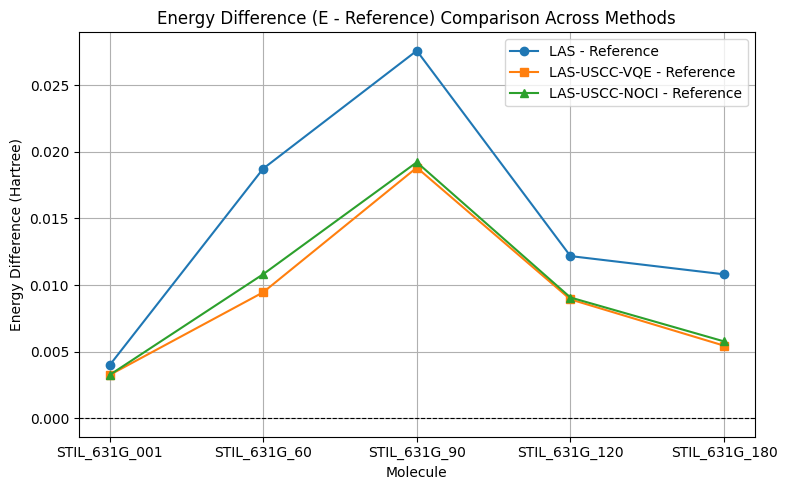

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Data setup
data = {
    "Molecule": ["STIL_631G_001", "STIL_631G_60", "STIL_631G_90", "STIL_631G_120", "STIL_631G_180"],
    "Reference": [-537.05893356256899551, -537.00826399867219152, -536.98234515925025789, -537.01149578726699474, -537.06572788840185240],
    "LAS": [-537.05495888450911934, -536.98953284992137469, -536.95476584646155516, -536.99932388089030155, -537.05492425995907979],
    "USCC": [-537.05568516572373028, -536.99880862845338925, -536.96353502879026109, -537.00257174447756370, -537.06027662846065596],
    "USCC_NOCI": [-537.05568377725603568, -536.99745263768488712, -536.96313408701473691, -537.00243061440039583, -537.05995659893881111],
}

df = pd.DataFrame(data)

# Compute energy differences
df["LAS_diff"] = df["LAS"] - df["Reference"]
df["USCC_diff"] = df["USCC"] - df["Reference"]
df["USCC_NOCI_diff"] = df["USCC_NOCI"] - df["Reference"]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(df["Molecule"], df["LAS_diff"], marker='o', label="LAS - Reference")
plt.plot(df["Molecule"], df["USCC_diff"], marker='s', label="LAS-USCC-VQE - Reference")
plt.plot(df["Molecule"], df["USCC_NOCI_diff"], marker='^', label="LAS-USCC-NOCI - Reference")
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.title("Energy Difference (E - Reference) Comparison Across Methods")
plt.xlabel("Molecule")
plt.ylabel("Energy Difference (Hartree)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


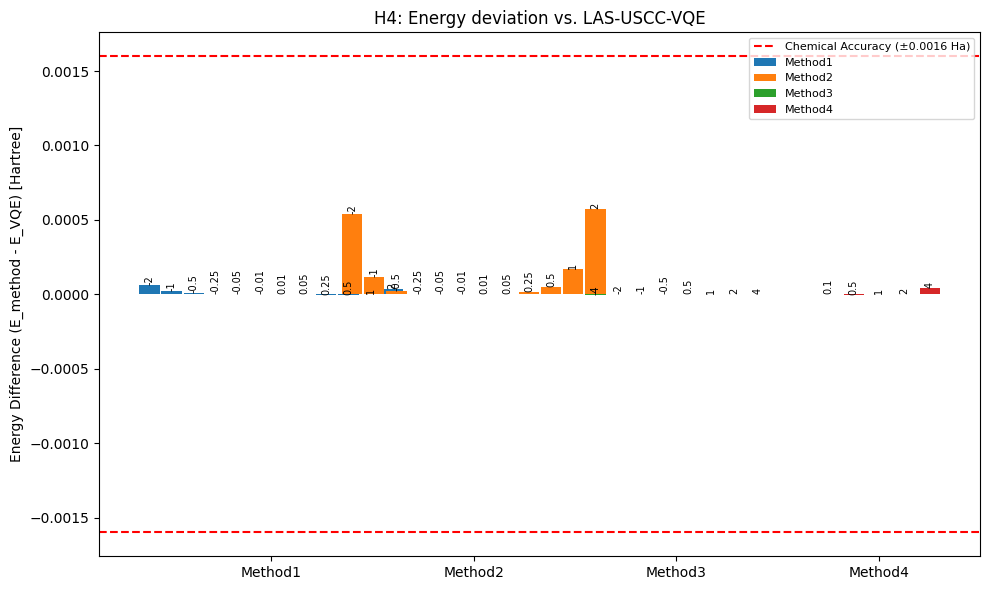

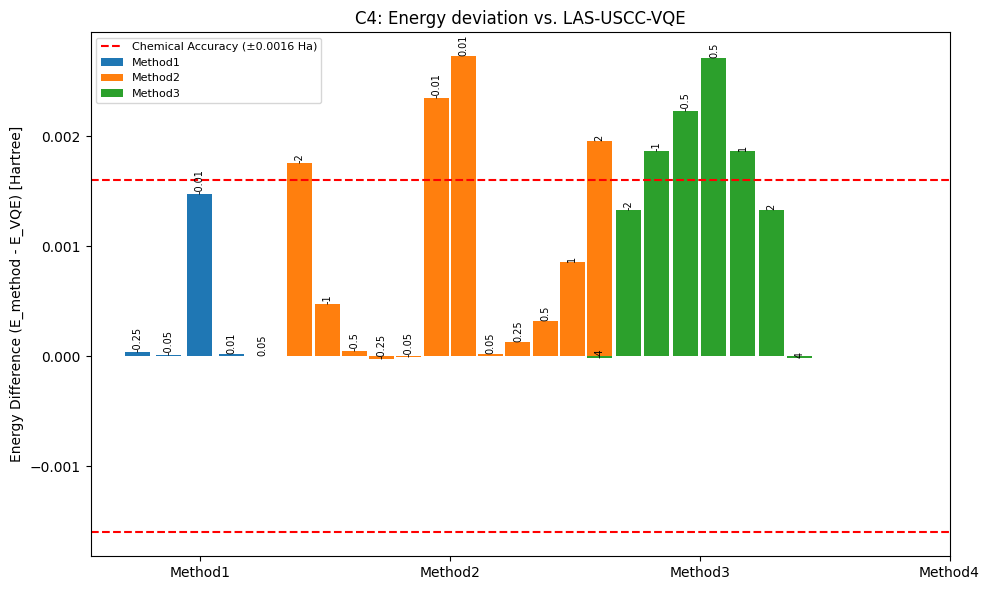

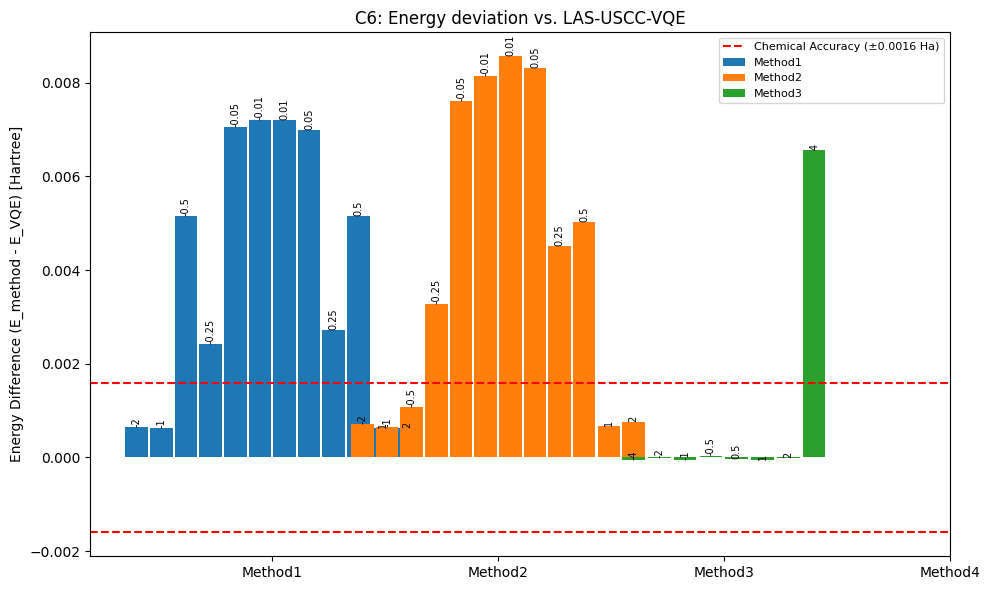

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Input core LAS-USCC-VQE reference energies ===
vqe_ref = {
    'H4': -2.18342595282445373,
    'C4': -154.91709587,
    'C6': -231.81122469935641561,
}

# === Example compact dictionary of your data ===
data = {
    'H4': {
        'Method1': { -0.01:-2.183425698, -0.05:-2.183425249, -0.25:-2.183422346,
                     -0.5:-2.183417214, -1:-2.183402327, -2:-2.183361863,
                      0.01:-2.183425905, 0.05:-2.183426287, 0.25:-2.18342752,
                      0.5:-2.183427441, 1:-2.183421707, 2:-2.183388722 },
        'Method2': { -0.01:-2.18342612, -0.05:-2.1834271, -0.25:-2.183425037,
                     -0.5:-2.183405661, -1:-2.183307771, -2:-2.18288836,
                      0.01:-2.183425458, 0.05:-2.183423793, 0.25:-2.183408728,
                      0.5:-2.183374424, 1:-2.18325612, 2:-2.182854555 },
        'Method3': { -0.5:-2.183426133, -1:-2.183426431, -2:-2.183426935, -4:-2.183427566,
                      0.5:-2.183425442, 1:-2.183425051, 2:-2.183424175, 4:-2.183422052 },
        'Method4': { 0.1:-2.1834259, 0.5:-2.183427395, 1:-2.183426004,
                      2:-2.183426785, 4:-2.183384245 },
    },
    'C4': {
        'Method1': { -0.01:-154.9156203, -0.05:-154.9170848, -0.25:-154.9170606,
                      0.01:-154.9170773, 0.05:-154.9170956 },
        'Method2': { -0.01:-154.9147518, -0.05:-154.9171034, -0.25:-154.9171179,
                     -0.5:-154.9170448, -1:-154.9166225, -2:-154.9153388,
                      0.01:-154.9143688, 0.05:-154.9170729, 0.25:-154.9169693,
                      0.5:-154.9167725, 1:-154.9162376, 2:-154.9151428 },
        'Method3': { -0.5:-154.9148689, -1:-154.91523, -2:-154.9157668, -4:-154.9171113,
                      0.5:-154.9143845, 1:-154.91523, 2:-154.9157668, 4:-154.9171113 },
        'Method4': { }, # empty
    },
    'C6': {
        'Method1': { -0.01:-231.8040125, -0.05:-231.8041708, -0.25:-231.8088011,
                     -0.5:-231.8060631, -1:-231.8105868, -2:-231.8105792,
                      0.01:-231.8040125, 0.05:-231.8042299, 0.25:-231.80851,
                      0.5:-231.8060631, 1:-231.8105869, 2:-231.8105868 },
        'Method2': { -0.01:-231.8030774, -0.05:-231.8036256, -0.25:-231.8079385,
                     -0.5:-231.810151, -1:-231.8105783, -2:-231.8105051,
                      0.01:-231.8026585, 0.05:-231.8029061, 0.25:-231.8067208,
                      0.5:-231.8061935, 1:-231.8105609, 2:-231.8104693 },
        'Method3': { -0.5:-231.8111948, -1:-231.8112783, -2:-231.8112444,
                     -4:-231.8112736, 0.5:-231.8112651, 1:-231.8112778,
                      2:-231.8112272, 4:-231.8046603 },
        'Method4': {},
    },
}

CHEM_ACCURACY = 0.0016  # Hartree ≈ 1 kcal/mol

# === Plotting ===
for mol, mol_data in data.items():
    ref = vqe_ref[mol]
    methods = list(mol_data.keys())

    fig, ax = plt.subplots(figsize=(10, 6))
    bar_width = 0.1
    offsets = np.linspace(-1.5, 1.5, 6)

    for i, (method, vals) in enumerate(mol_data.items()):
        if not vals:
            continue
        c_vals = sorted(vals.keys())
        energies = [vals[c] for c in c_vals]
        diff = [e - ref for e in energies]

        x = np.full(len(c_vals), i) + np.linspace(-bar_width*len(c_vals)/2,
                                                  bar_width*len(c_vals)/2,
                                                  len(c_vals))
        ax.bar(x, diff, width=bar_width, label=f"{method}")

        # Annotate each bar with c
        for xi, di, ci in zip(x, diff, c_vals):
            ax.text(xi, di, f"{ci}", ha='center', va='bottom', fontsize=7, rotation=90)

    ax.axhline(CHEM_ACCURACY, color='red', linestyle='--', label='Chemical Accuracy (±0.0016 Ha)')
    ax.axhline(-CHEM_ACCURACY, color='red', linestyle='--')

    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods)
    ax.set_ylabel("Energy Difference (E_method - E_VQE) [Hartree]")
    ax.set_title(f"{mol}: Energy deviation vs. LAS-USCC-VQE")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_energy_rel_to_min_noqe(molecule, t_vals, vqe, noqe, cond):
    # Reference: lowest NOQE energy
    ref_energy = min(vqe)
    vqe_rel = (vqe - ref_energy) * 1000  # mEh
    noqe_rel = (noqe - ref_energy) * 1000

    fig, ax1 = plt.subplots(figsize=(7,4))
    
    # Left y-axis: absolute energies relative to min NOQE (mEh)
    ax1.plot(t_vals, vqe_rel, 'o--', color='tab:green', label='LAS-USCCSD (VQE)')
    ax1.plot(t_vals, noqe_rel, 's--', color='tab:orange', label='LAS-USCCSD (NOQE)')
    ax1.axhline(y=0, color='black', linewidth=0.8)
    ax1.set_xlabel('Excitation strength (t)')
    ax1.set_ylabel('Energy relative to min VQE (mEh)')
    ax1.tick_params(axis='y')
    ax1.legend(loc='upper left', fontsize=8)
    
    # Right y-axis: condition number
    ax2 = ax1.twinx()
    ax2.plot(t_vals, cond, 'd-', color='tab:red', label='Condition number')
    ax2.set_yscale('log')
    ax2.set_ylabel('Condition number (log scale)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.legend(loc='upper right', fontsize=8)
    
    plt.title(f'{molecule}: Energy (mEh, min NOQE=0) and Condition Number vs t')
    plt.tight_layout()
    path = f".{molecule}_energy_condition_mEh_minNOQE.png"
    plt.savefig(path, dpi=300)
    plt.close()
    return path


# H4 data
t_H4 = np.array([0.01, 0.05, 0.25, 0.5, 1, 2])
vqe_H4 = np.array([-2.183425953]*6)
noqe_H4 = np.array([-2.183425905, -2.183426287, -2.18342752, -2.183427441, -2.183421707, -2.183388722])
cond_H4 = np.array([1851633, 73806, 2703, 510, 38, 7])
p_H4 = plot_energy_rel_to_min_noqe("H4", t_H4, vqe_H4, noqe_H4, cond_H4)

# C4 data
t_C4 = np.array([0.01, 0.05, 0.25, 0.5, 1, 2])
vqe_C4 = np.array([-154.9170959]*6)
noqe_C4 = np.array([-154.9143688, -154.9170729, -154.9169693, -154.9167725, -154.9162376, -154.9151428])
cond_C4 = np.array([94987, 71601, 2622, 495, 38, 6])
p_C4 = plot_energy_rel_to_min_noqe("C4", t_C4, vqe_C4, noqe_C4, cond_C4)

# C6 data
t_C6 = np.array([0.01, 0.05, 0.25, 0.5, 1, 2])
vqe_C6 = np.array([-231.8112247]*6)
noqe_C6 = np.array([-231.8040125, -231.8042299, -231.80851, -231.8060631, -231.8105869, -231.8105868])
cond_C6 = np.array([93537, 90975, 99672, 97367, 77229, 33706])
p_C6 = plot_energy_rel_to_min_noqe("C6", t_C6, vqe_C6, noqe_C6, cond_C6)

p_H4, p_C4, p_C6


('.H4_energy_condition_mEh_minNOQE.png',
 '.C4_energy_condition_mEh_minNOQE.png',
 '.C6_energy_condition_mEh_minNOQE.png')

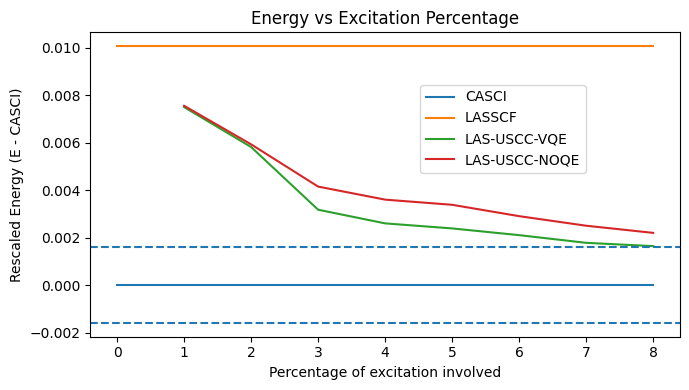

In [16]:
import matplotlib.pyplot as plt

# x axis
pct = list(range(0,9))

# energies
CASCI = [-231.812763066916]*9
LASSCF = [-231.802702889877]*9

VQE = [None, -231.805268338037, -231.806950486983, -231.809590678873,
       -231.810166147722, -231.810378472976, -231.810661880054,
       -231.810985137591, -231.811124116977]

NOQI = [None, -231.805213461507, -231.806837715359, -231.808616604556,
        -231.809166299701, -231.809383283183, -231.809862019045,
        -231.810264773368, -231.810565674026]

# rescale relative to CASCI
CASCI_r = [0]*9
LASSCF_r = [e - CASCI[0] for e in LASSCF]
VQE_r = [v - CASCI[0] if v is not None else None for v in VQE]
NOQI_r = [v - CASCI[0] if v is not None else None for v in NOQI]

# chemical accuracy in Hartree
chem_acc = 0.001593601

plt.figure(figsize=(7,4))

plt.plot(pct, CASCI_r, label="CASCI")
plt.plot(pct, LASSCF_r, label="LASSCF")
plt.plot(pct, VQE_r, label="LAS-USCC-VQE")
plt.plot(pct, NOQI_r, label="LAS-USCC-NOQE")

# chemical accuracy band
plt.axhline(chem_acc, linestyle="--")
plt.axhline(-chem_acc, linestyle="--")

plt.xlabel("Percentage of excitation involved")
plt.ylabel("Rescaled Energy (E - CASCI)")
plt.title("Energy vs Excitation Percentage")

# move legend upward slightly
plt.legend(loc="upper center", bbox_to_anchor=(0.7, 0.85))

plt.tight_layout()
plt.show()


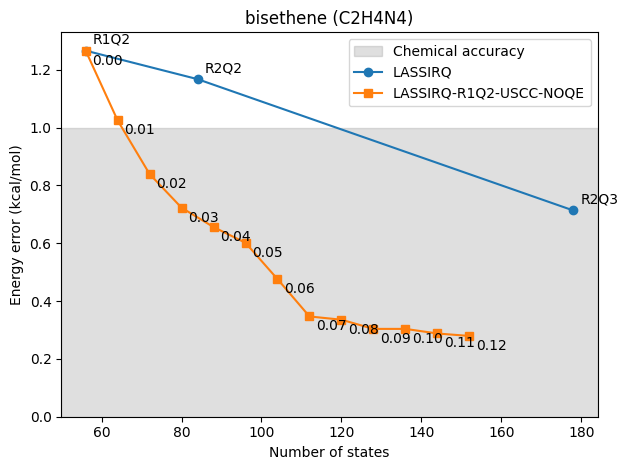

In [17]:
# Re-plot with shaded chemical accuracy region using explicit gray color
# matching: ax.axhspan(0, chemical_accuracy_kcal, color='gray', alpha=shade_alpha, zorder=0)

import matplotlib.pyplot as plt

HARTREE_TO_KCAL = 627.509
E_ref = -295.6472696
chemical_accuracy_kcal = 1.0
shade_alpha = 0.25

lassirq = [
    ("R1Q2", 56, -295.6452514),
    ("R2Q2", 84, -295.6454086),
    ("R2Q3", 178, -295.6461324),
]

lcc = [
    ("0.00", 56, -295.6452514),
    ("0.01", 64, -295.645636),
    ("0.02", 72, -295.6459318),
    ("0.03", 80, -295.6461175),
    ("0.04", 88, -295.646224),
    ("0.05", 96, -295.6463108),
    ("0.06", 104, -295.6465108),
    ("0.07", 112, -295.6467168),
    ("0.08", 120, -295.6467348),
    ("0.09", 128, -295.6467854),
    ("0.10", 136, -295.6467854),
    ("0.11", 144, -295.6468108),
    ("0.12", 152, -295.6468243),
]

x_lassirq = [n for _, n, _ in lassirq]
y_lassirq = [(E - E_ref) * HARTREE_TO_KCAL for _, _, E in lassirq]
labels_lassirq = [cfg for cfg, _, _ in lassirq]

x_lcc = [n for _, n, _ in lcc]
y_lcc = [(E - E_ref) * HARTREE_TO_KCAL for _, _, E in lcc]
labels_lcc = [cfg for cfg, _, _ in lcc]

fig, ax = plt.subplots()

# Shaded chemical accuracy region (explicit gray)
ax.axhspan(
    0,
    chemical_accuracy_kcal,
    color='gray',
    alpha=shade_alpha,
    zorder=0,
    label='Chemical accuracy'
)

# Curves
ax.plot(x_lassirq, y_lassirq, marker='o', label='LASSIRQ', zorder=3)
ax.plot(x_lcc, y_lcc, marker='s', label='LASSIRQ-R1Q2-USCC-NOQE', zorder=3)

# Chemical accuracy line
# ax.axhline(
#     chemical_accuracy_kcal,
#     linestyle='--',
#     zorder=2,
#     label='Chemical accuracy'
# )

# Annotations
for x, y, label in zip(x_lassirq, y_lassirq, labels_lassirq):
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(5, 5))

for x, y, label in zip(x_lcc, y_lcc, labels_lcc):
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(5, -10))

ax.set_xlabel("Number of states")
ax.set_ylabel("Energy error (kcal/mol)")
ax.set_ylim(bottom=0)
ax.set_title("bisethene (C2H4N4)")

ax.legend()
fig.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_energy_error_vs_fraction(
    casci_energy: float,
    lasci_energy: float,
    las_uscc_vqe_energy,
    las_lscc_energy,
    fraction,
    molecule_name: str,
    hartree_to_kcal: float = 627.509,
    chemical_accuracy_kcal: float = 1.0,
    shade_alpha: float = 0.12,
    per_fragment_divisor: float | None = None,  # e.g. 4 for C8; set None to disable
    show: bool = True,
):
    """
    Plot absolute energy error (kcal/mol) vs fraction/excitation percentage, using CASCI as reference.

    Parameters
    ----------
    casci_energy : float
        CASCI reference energy (Hartree).
    lasci_energy : float
        LAS / LASSCF baseline energy (Hartree). Used to draw a horizontal reference line ("LAS").
    las_uscc_vqe_energy : array-like
        Energies for LAS-USCC-VQE (Hartree), same length as fraction.
    las_lscc_energy : array-like
        Energies for LAS-LSCC (Hartree), same length as fraction.
    fraction : array-like
        X-axis values (fraction or excitation percentage).
    molecule_name : str
        Title of the plot.
    hartree_to_kcal : float
        Conversion factor (default 627.509).
    chemical_accuracy_kcal : float
        Chemical accuracy threshold in kcal/mol (default 1.0).
    shade_alpha : float
        Alpha for shading region below chemical accuracy.
    per_fragment_divisor : float | None
        If set (e.g., 4), also plot per-fragment errors by dividing the error curves by this number,
        with same color but increased transparency.
    show : bool
        Whether to call plt.show().

    Returns
    -------
    fig, ax
        Matplotlib figure and axes.
    """
    x = np.asarray(fraction, dtype=float)
    e_vqe = np.asarray(las_uscc_vqe_energy, dtype=float)
    e_lscc = np.asarray(las_lscc_energy, dtype=float)

    # absolute error in kcal/mol
    err_vqe = np.abs(e_vqe - casci_energy) * hartree_to_kcal
    err_lscc = np.abs(e_lscc - casci_energy) * hartree_to_kcal

    fig, ax = plt.subplots()

    # shaded chemical-accuracy region
    ax.axhspan(0, chemical_accuracy_kcal, color='gray', alpha=shade_alpha, zorder=0, label='Chemical accuracy')

    # main curves
    line_vqe, = ax.plot(x, err_vqe, marker='o', label='LAS-USCC-VQE')
    line_lscc, = ax.plot(x, err_lscc, marker='s', label='LAS-USCC-NOQE')

    # optional per-fragment curves: same color, more transparent
    if per_fragment_divisor is not None and per_fragment_divisor != 0:
        ax.plot(
            x, err_vqe / per_fragment_divisor,
            marker='o',
            color=line_vqe.get_color(),
            alpha=0.4,
            label=f'LAS-USCC-VQE per fragment (/{per_fragment_divisor:g})'
        )
        ax.plot(
            x, err_lscc / per_fragment_divisor,
            marker='s',
            color=line_lscc.get_color(),
            alpha=0.4,
            label=f'LAS-USCC-NOQE per fragment (/{per_fragment_divisor:g})'
        )

    # reference lines
    # ax.axhline(chemical_accuracy_kcal, linestyle='--', label=f'Chemical accuracy ({chemical_accuracy_kcal:g} kcal/mol)')
    ax.axhline(np.abs(lasci_energy - casci_energy) * hartree_to_kcal, linestyle='--', color='black', label='LAS')

    ax.set_xlabel('Excitation fraction')
    ax.set_ylabel('Energy error (kcal/mol)')
    ax.set_ylim(bottom=0)
    ax.set_title(molecule_name)
    ax.legend()

    if show:
        plt.show()

    return fig, ax


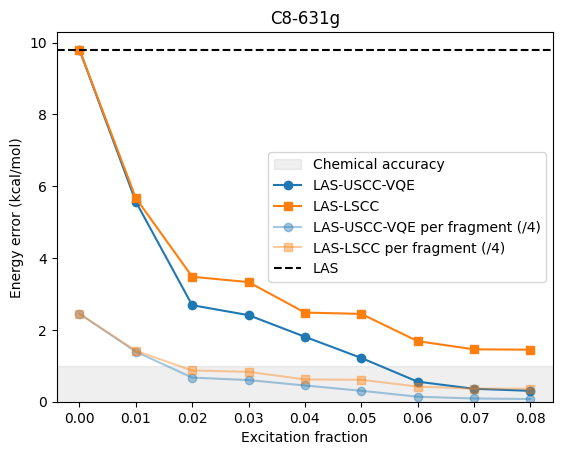

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'C8-631g'}, xlabel='Excitation fraction', ylabel='Energy error (kcal/mol)'>)

In [24]:
fraction = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
casci = -308.7021646057013
lasci = -308.6865445265418
las_uscc_vqe = [-308.686544526542, -308.6932874, -308.6978817, -308.6983225, -308.6992831, -308.7002227, -308.7012751, -308.7015909, -308.7016823]
las_lscc = [-308.686544526542, -308.6931252, -308.6966185, -308.696856922, -308.6982089, -308.6982673, -308.699477, -308.6998392, -308.6998561]

plot_energy_error_vs_fraction(
    casci_energy=casci,
    lasci_energy=lasci,
    las_uscc_vqe_energy=las_uscc_vqe,
    las_lscc_energy=las_lscc,
    fraction=fraction,
    molecule_name="C8-631g",
    per_fragment_divisor=4,  # 不需要就设 None
)


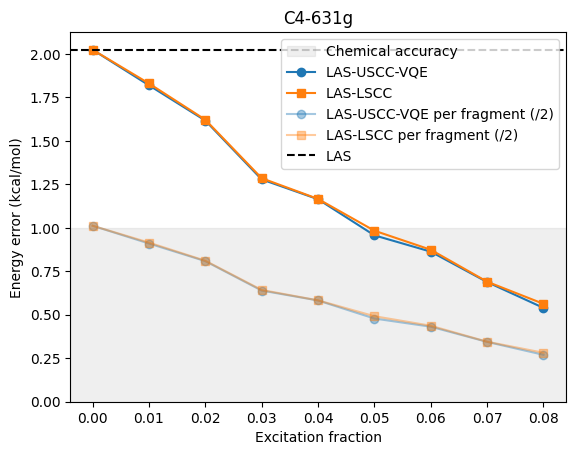

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'C4-631g'}, xlabel='Excitation fraction', ylabel='Energy error (kcal/mol)'>)

In [20]:
fraction = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
casci = -154.91764545394244
lasci =      -154.91442004941376 # las
las_uscc_vqe = [
    -154.91442004941376, # las
    -154.914745914,
    -154.915068988,
    -154.915608184,
    -154.915790024,
    -154.916120814,
    -154.916270361,
    -154.916548976,
    -154.916785657,
]

las_lscc = [
    -154.91442004941376,
    -154.914729000,
    -154.915061585,
    -154.915597184,
    -154.915787413,
    -154.916078396,
    -154.916252847,
    -154.916545685,
    -154.916748523,
]
plot_energy_error_vs_fraction(
    casci_energy=casci,
    lasci_energy=lasci,
    las_uscc_vqe_energy=las_uscc_vqe,
    las_lscc_energy=las_lscc,
    fraction=fraction,
    molecule_name="C4-631g",
    per_fragment_divisor=2,  # 不需要就设 None
)


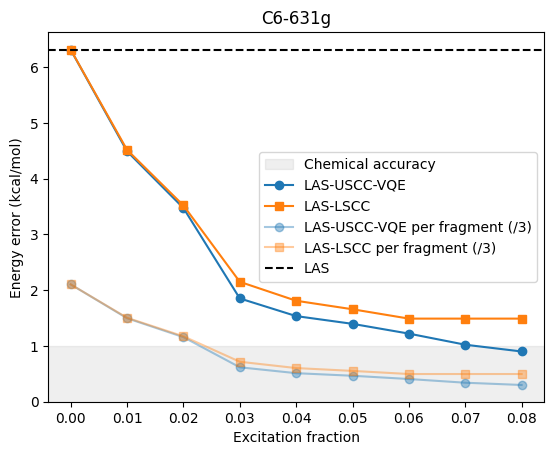

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'C6-631g'}, xlabel='Excitation fraction', ylabel='Energy error (kcal/mol)'>)

In [21]:
fraction = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
casci = -231.812763066916
lasci =        -231.8027028898771
las_uscc_vqe = [
    -231.8027028898771,
    -231.805605780,
    -231.807227414,
    -231.809811124,
    -231.810315904,
    -231.810537374,
    -231.810816565,
    -231.811133856,
    -231.811327359,
]

las_lscc = [
    -231.8027028898771,
    -231.805564934,
    -231.807153954,
    -231.809336444,
    -231.809877403,
    -231.810120698,
    -231.810387843,
    -231.810387843,
    -231.810387843,
]
plot_energy_error_vs_fraction(
    casci_energy=casci,
    lasci_energy=lasci,
    las_uscc_vqe_energy=las_uscc_vqe,
    las_lscc_energy=las_lscc,
    fraction=fraction,
    molecule_name="C6-631g",
    per_fragment_divisor=3,  # 不需要就设 None
)


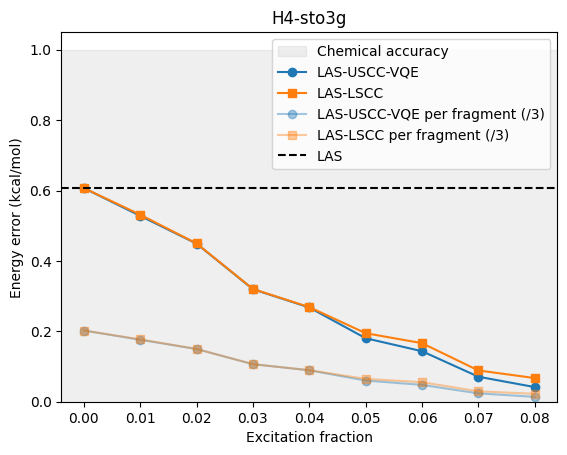

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'H4-sto3g'}, xlabel='Excitation fraction', ylabel='Energy error (kcal/mol)'>)

In [22]:
fraction = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
casci = -2.1834470548912863
lasci =         -2.1824798417552316
las_uscc_vqe = [
     -2.1824798417552316,
    -2.182605545,
    -2.182731354,
    -2.182937736,
    -2.183020384,
    -2.183159544,
    -2.183218392,
    -2.183333868,
    -2.183380793,
]

las_lscc = [
    -2.1824798417552316,
    -2.182600190,
    -2.182730573,
    -2.182936609,
    -2.183018735,
    -2.183136832,
    -2.183181958,
    -2.183305483,
    -2.183339916,
]
plot_energy_error_vs_fraction(
    casci_energy=casci,
    lasci_energy=lasci,
    las_uscc_vqe_energy=las_uscc_vqe,
    las_lscc_energy=las_lscc,
    fraction=fraction,
    molecule_name="H4-sto3g",
    per_fragment_divisor=3,  # 不需要就设 None
)
